(10320,)
(10312, 8, 1)
15135.685427172226


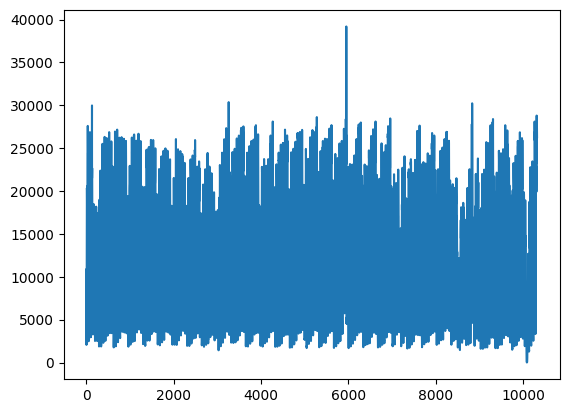

In [5]:
import numpy
import matplotlib.pyplot as plt
import pandas as pd

import pycatch22
import AILibs

def load_data(file_path, mw_column_name = "value"):
    # 1. Load the CSV
    df = pd.read_csv(file_path)
    
    # 2. Convert Datetime from string to datetime objects
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # 3. Set index and sort chronologically (crucial for time series!)
    df = df.set_index('timestamp').sort_index()
    
    # 4. Rename the column to a standardized name
    df = df.rename(columns={mw_column_name: 'value'})

    x = numpy.array(df["value"].values)
    
    return x

def create_sliding_windows(series, window_size):
    X, y = [], []
    # Convert dataframe column to numpy array
    
    for i in range(len(series) - window_size):
        # Input: sequence from i to i + window_size
        X.append(series[i : i + window_size])

    X = numpy.array(X)
    X = numpy.expand_dims(X, axis=-1)  # add feature dimension

    return X


# load datset
dataset_root_path = "/users/michal/datasets/anomaly/realKnownCause/nyc_taxi.csv"
#dataset_root_path = "/users/michal/datasets/anomaly/realKnownCause/machine_temperature_system_failure.csv"
#dataset_root_path = "/users/michal/datasets/anomaly/realKnownCause/rogue_agent_key_hold.csv"
#dataset_root_path = "/users/michal/datasets/anomaly/realKnownCause/ec2_request_latency_system_failure.csv"

x_orig = load_data(dataset_root_path, 'value')

#x_orig = x_orig[0:5000]

x_window = create_sliding_windows(x_orig, window_size=8)

print(x_orig.shape)     
print(x_window.shape)
print(x_window.mean())


plt.plot(x_orig)
plt.show()

In [6]:
'''
z = []
for n in range(len(x_window)):
   z_tmp = pycatch22.catch22_all(x_window[n])["values"]

   z.append(z_tmp)

   print(n, len(x_window))

z = numpy.array(z)
'''

z = x_window[:, :, 0]


In [7]:

print("Fitting Isolation Forest...")

forest = AILibs.forest.IsolationForest()

forest.fit(z, max_depth=8, num_trees=256, num_subsamples=256)


print("Predicting with Isolation Forest...")       
scores = forest.predict(z)  
    

Fitting Isolation Forest...
Predicting with Isolation Forest...


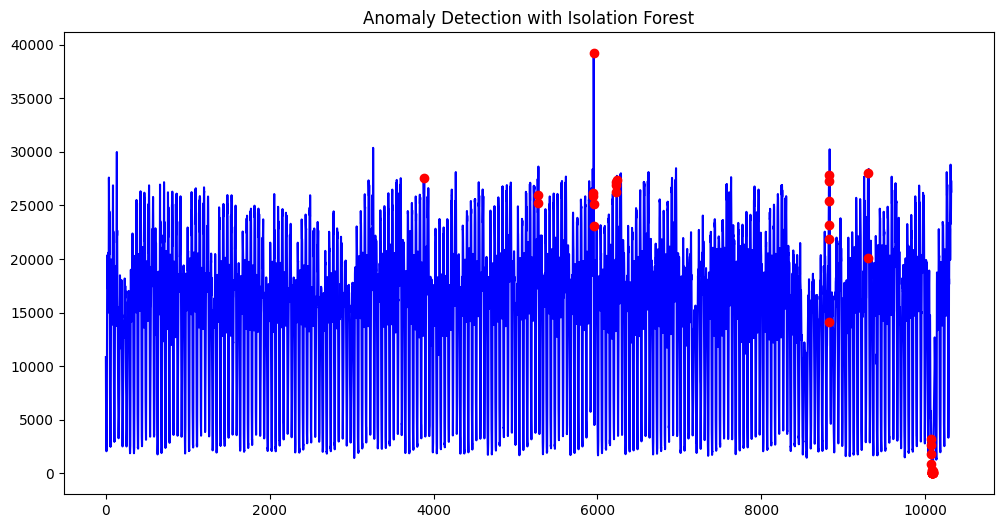

In [13]:

indices = numpy.where(scores > 0.77)[0]

time_steps = numpy.arange(len(x_orig))
time_steps = time_steps[indices]
scores_th  = x_orig[indices]

# plot dots on top of the original time series
plt.figure(figsize=(12, 6))
plt.title("Anomaly Detection with Isolation Forest")
plt.plot(x_orig,color="blue", label="Data")
plt.scatter(time_steps, scores_th, color="red", label="Anomalies", zorder=5)
plt.show()